# Pipeline xử lý dữ liệu Creator

**Đầu vào:** `results_success.jsonl`  
**Đầu ra:** `creators_processed.csv`

| Bước | Notebook gốc | Mô tả |
|------|-------------|-------|
| 1 | `collect.ipynb` | Parse JSONL → gom creator + video, deduplicate |
| 2 | `expand.ipynb` | Lọc thiếu, mở rộng cột phân phối |
| 3 | `feature_engineering.ipynb` | Tính đặc trưng cấp creator |
| 4 | `processing.ipynb` | Xóa cột thừa, điền giá trị thiếu |

## 0. Import thư viện

In [1]:
import json
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

INPUT_FILE  = 'results_success.jsonl'
OUTPUT_FILE = 'creators_processed_2.csv'

## Bước 1 — Thu thập dữ liệu

Đọc từng dòng JSONL, trích xuất thông tin creator (profile, credit score, 
thống kê hiệu suất, phân phối audience) và danh sách video gần đây.  
Dùng `dict` để **deduplicate** creator theo `aioCreatorID` và video theo `itemID`.
Mỗi dòng cuối cùng trong DataFrame tương ứng với **1 video** của 1 creator.

In [ ]:
def _safe_first(lst):
    """Lấy phần tử đầu tiên của list một cách an toàn."""
    return lst[0] if isinstance(lst, list) and lst else {}


def collect_creators(input_file: str) -> pd.DataFrame:
    """
    Parse file JSONL, gom thông tin creator + video.
    Trả về DataFrame với mỗi dòng là 1 video.
    """
    creators_master: dict = {}

    def _update(target, src, mapping):
        """Chỉ ghi nếu key chưa có VÀ giá trị không rỗng."""
        for key, path in mapping.items():
            val = src.get(path)
            if val is not None and val != '' and key not in target:
                target[key] = val

    with open(input_file, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            try:
                line_data = json.loads(line)
            except json.JSONDecodeError:
                continue

            for req in line_data.get('requests', []):
                body_raw = req.get('body_raw')
                if not body_raw:
                    continue
                try:
                    creators = json.loads(body_raw).get('creators', [])
                except (json.JSONDecodeError, AttributeError):
                    continue

                for c in creators:
                    cid = c.get('aioCreatorID')
                    if not cid:
                        continue

                    if cid not in creators_master:
                        creators_master[cid] = {'info': {}, 'videos': {}}

                    master   = creators_master[cid]
                    tt_info  = c.get('creatorTTInfo', {})
                    es_data  = c.get('esData', {})
                    price    = es_data.get('price', {})
                    cs       = c.get('creditScore', {})
                    ri       = c.get('riskInfo', {})
                    cvs      = c.get('creatorValueStat', {})
                    stat     = c.get('statisticData', {})
                    op       = stat.get('overallPerformance', {})
                    fdd      = stat.get('followerDistriData', {})

                    if isinstance(op, list):
                        op = _safe_first(op)

                    _update(master['info'], op, {
                        'avgSixSecondsViewsBenchMarkViews': 'avgSixSecondsViewsBenchMarkViews',
                        'avgSixSecondsViewsRate':           'avgSixSecondsViewsRate',
                        'avgSixSecondsViewsRateRank':       'avgSixSecondsViewsRateRank',
                        'engagementRateBenchMark':          'engagementRateBenchMark',
                        'engagementRateRank':               'engagementRateRank',
                        'followerTier':                     'followerTier',
                        'followersGrowthRate':              'followersGrowthRate',
                        'followersGrowthRateRank':          'followersGrowthRateRank',
                        'medianBenchMarkViews':             'medianBenchMarkViews',
                        'medianViewsRank':                  'medianViewsRank',
                        'videoCompleteRate':                'videoCompleteRate',
                        'videoCompleteRateRank':            'videoCompleteRateRank',
                        'engagementRate':                   'engagementRate',
                        'medianViews':                      'medianViews',
                    })
                    _update(master['info'], tt_info, {
                        'tiktokUID':   'ttUID',
                        'nickname':    'nickName',
                        'handleName':  'handleName',
                        'followerCnt': 'followerCnt',
                    })
                    _update(master['info'], c,     {'displayType':       'displayType'})
                    _update(master['info'], price, {
                        'recommendRate100k': 'recommendRate100k',
                        'startingRate100k':  'startingRate100k',
                    })
                    _update(master['info'], cs, {
                        'currentScore':    'currentScore',
                        'currentTier':     'currentTier',
                        'scoreLowerLimit': 'scoreLowerLimit',
                        'scoreUpperLimit': 'scoreUpperLimit',
                    })
                    _update(master['info'], cvs, {
                        'broadcastingScore':   'broadcastingScore',
                        'collaborationScore':  'collaborationScore',
                        'commercialScore':     'commercialScore',
                        'comprehensiveScore':  'comprehensiveScore',
                    })

                    if c.get('contentLabels'):
                        master['info']['contentLabels'] = '|'.join(
                            lbl.get('labelName', '') for lbl in c['contentLabels']
                        )

                    dil = ri.get('disciplineInfoList')
                    if dil:
                        d = _safe_first(dil)
                        master['info']['disciplineStatus'] = d.get('disciplineStatus')
                        master['info']['disciplineType']   = d.get('disciplineType')

                    rel = ri.get('riskEventInfoList')
                    if rel:
                        r = _safe_first(rel)
                        master['info']['riskEventStatus'] = r.get('riskEventStatus')
                        master['info']['riskEventType']   = r.get('riskEventType')

                    for stat_key in ['active', 'age', 'deviceBrand', 'gender', 'region']:
                        if fdd.get(stat_key):
                            master['info'][f'{stat_key}_dist'] = str(fdd[stat_key])

                    for v in c.get('recentItems', []):
                        vid = v.get('itemID')
                        if vid:
                            master['videos'][vid] = {
                                'video_itemID':     vid,
                                'video_title':      v.get('title'),
                                'video_views':      v.get('views'),
                                'video_heart':      v.get('heart'),
                                'video_comment':    v.get('comment'),
                                'video_share':      v.get('share'),
                                'video_createTime': v.get('createTime'),
                            }

    final_rows = []
    for cid, data in creators_master.items():
        base = {'aioCreatorID': cid, **data['info']}
        if data['videos']:
            for v_info in data['videos'].values():
                final_rows.append({**base, **v_info})
        else:
            final_rows.append(base)

    df = pd.DataFrame(final_rows)
    print(f'[collect] {df["aioCreatorID"].nunique():,} creators | {len(df):,} dòng video')
    return df


# df = collect_creators(INPUT_FILE)

[collect] 9,935 creators | 144,249 dòng video


Entertainment Creator of the Year - Nhà sáng tạo nội dung Giải trí của năm
Sport Creator of the Year - Nhà sáng tạo nội dung Thể thao của năm
Beauty Creator of the Year - Nhà sáng tạo nội dung Làm đẹp của năm
Food Creator of the Year - Nhà sáng tạo nội dung Ẩm thực của năm
Education Creator of the Year - Nhà sáng tạo nội dung Giáo dục của năm

In [ ]:
# target_labels = {
#     'Nail Art & Care',
#     'Beauty Tutorials & Tips',
#     'Hair Design & Care'
# }

# df['contentLabels_list'] = df['contentLabels'].str.split('|')

# df = df[
#     df['contentLabels_list'].apply(lambda x: any(label in target_labels for label in x))
# ]

In [ ]:
# target_labels = {
#     'Movies & TV',
#     'Theater & Stage',
#     'Music',
#     'Dance',
#     'Animation & Cosplay',
#     'Entertainment News',
#     'Supernatural & Horror'
# }

# df['contentLabels_list'] = df['contentLabels'].str.split('|')

# df = df[
#     df['contentLabels_list'].apply(lambda x: any(label in target_labels for label in x))
# ]

In [ ]:
# # Fitness
# # Health & Wellness
# # Fishing, Hunting, & Camping
# # Traditional Sports
# # Extreme Sports
# # Sports News

# Food Display & Reviews
# Beverages & Production
# Mukbang & Food Tasting
# Cooking & Recipes
# Restaurant Exploration



In [ ]:
# df.shape

(144249, 47)

## Bước 2 — Mở rộng cột phân phối

- Thay thế các chuỗi rỗng / `'null'` bằng `NaN`.
- Bỏ creator thiếu `currentTier` (chưa được đánh giá) hoặc thiếu `video_createTime`.
- Parse các cột `*_dist` (dạng chuỗi JSON list) thành các cột số riêng biệt,
  mỗi cột tương ứng với một phân khúc audience (ví dụ `age_18-24`, `gender_female`…).

In [89]:
# Chuẩn hóa giá trị thiếu
MISSING_TOKENS = ['', ' ', 'na', 'Na', 'NA', 'null', 'Null', 'None']
df = df.replace(MISSING_TOKENS, np.nan)

# Bỏ creator không có đủ thông tin cốt lõi
df = df.dropna(subset=['video_createTime'])
print(f'[expand] Sau khi lọc: {df["aioCreatorID"].nunique():,} creators | {len(df):,} dòng')


def expand_dist_column(series: pd.Series, key_name: str) -> pd.DataFrame:
    """
    Parse cột phân phối dạng list-of-dict thành DataFrame.
    Mỗi key_name trở thành 1 cột với giá trị là ratio.
    """
    def _parse(x):
        if pd.isna(x) or x in ('', 'null'):
            return {}
        if isinstance(x, str):
            try:
                x = ast.literal_eval(x)
            except Exception:
                return {}
        if not isinstance(x, list):
            return {}
        return {
            item[key_name]: item['ratio']
            for item in x
            if isinstance(item, dict)
            and item.get(key_name) is not None
            and item.get('ratio') is not None
        }
    return series.apply(_parse).apply(pd.Series)


df_active  = expand_dist_column(df['active_dist'],      'active').add_prefix('active_')
df_age     = expand_dist_column(df['age_dist'],         'ageInterval').add_prefix('age_')
df_device  = expand_dist_column(df['deviceBrand_dist'], 'deviceBrand').add_prefix('device_')
df_gender  = expand_dist_column(df['gender_dist'],      'gender').add_prefix('gender_')
df_country = expand_dist_column(df['region_dist'],      'country').add_prefix('country_')

df = pd.concat([df, df_active, df_age, df_device, df_gender, df_country], axis=1)
print(f'[expand] Số cột sau khi mở rộng: {df.shape[1]}')

[expand] Sau khi lọc: 9,918 creators | 144,218 dòng
[expand] Số cột sau khi mở rộng: 173


In [ ]:
# df.to_csv('creator_expand.csv', index=False)

In [2]:
df = pd.read_csv('creator_expand.csv')

In [3]:
df[df['followersGrowthRate'] == 42037.0]

,aioCreatorID,tiktokUID,nickname,handleName,followerCnt,currentScore,currentTier,scoreLowerLimit,scoreUpperLimit,displayType,...,country_JM,country_DO,country_LY,country_IE,country_VI,country_DK,country_BG,country_CH,country_JO,country_IR
94911,7617489367124475920,7616344774057395220,châu moè,chau.moe2k5,42571,70.0,1.0,0.0,100.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94912,7617489367124475920,7616344774057395220,châu moè,chau.moe2k5,42571,70.0,1.0,0.0,100.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94913,7617489367124475920,7616344774057395220,châu moè,chau.moe2k5,42571,70.0,1.0,0.0,100.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94914,7617489367124475920,7616344774057395220,châu moè,chau.moe2k5,42571,70.0,1.0,0.0,100.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94915,7617489367124475920,7616344774057395220,châu moè,chau.moe2k5,42571,70.0,1.0,0.0,100.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94916,7617489367124475920,7616344774057395220,châu moè,chau.moe2k5,42571,70.0,1.0,0.0,100.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94917,7617489367124475920,7616344774057395220,châu moè,chau.moe2k5,42571,70.0,1.0,0.0,100.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94918,7617489367124475920,7616344774057395220,châu moè,chau.moe2k5,42571,70.0,1.0,0.0,100.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94919,7617489367124475920,7616344774057395220,châu moè,chau.moe2k5,42571,70.0,1.0,0.0,100.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94920,7617489367124475920,7616344774057395220,châu moè,chau.moe2k5,42571,70.0,1.0,0.0,100.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df['contentLabels'].isna().sum()


2456

In [4]:
df['contentLabels'] = df['contentLabels'].fillna('Unknown')

In [5]:
target_labels = {
    'School Education',
    'Career Development',
    'Humanities & Science'
    
    'Fitness'
    'Health & Wellness'
    'Fishing, Hunting, & Camping'
    'Traditional Sports'
    'Extreme Sports'
    'Sports News'

    'Food Display & Reviews',
    'Beverages & Production',
    'Mukbang & Food Tasting',
    'Cooking & Recipes',
    'Restaurant Exploration',

    'Nail Art & Care',
    'Beauty Tutorials & Tips',
    'Hair Design & Care',
    'Theater & Stage',

    'Music',
    'Dance',
    'Animation & Cosplay',
    'Entertainment News',
    'Supernatural & Horror'
}

df['contentLabels_list'] = df['contentLabels'].str.split('|')

df = df[
    df['contentLabels_list'].apply(lambda x: any(label in target_labels for label in x))
]

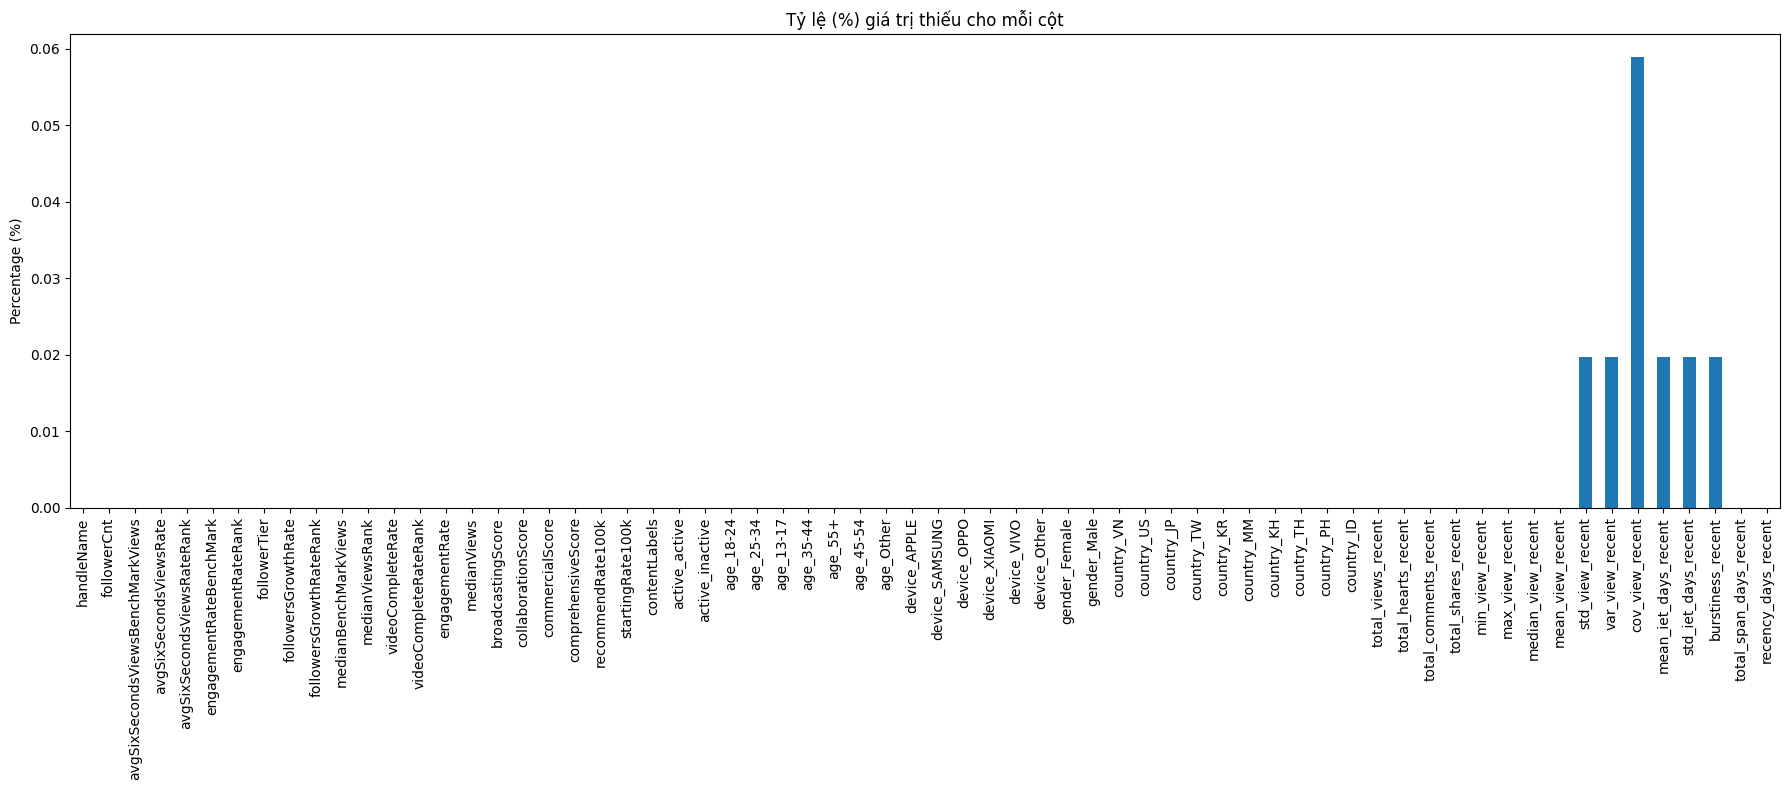

In [22]:
a = df.isna().mean() * 100  

plt.figure(figsize=(18, 8))
a.plot(kind='bar')

plt.title('Tỷ lệ (%) giá trị thiếu cho mỗi cột')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [ ]:
df.columns

Index(['handleName', 'followerCnt', 'avgSixSecondsViewsBenchMarkViews',
       'avgSixSecondsViewsRate', 'avgSixSecondsViewsRateRank',
       'engagementRateBenchMark', 'engagementRateRank', 'followerTier',
       'followersGrowthRate', 'followersGrowthRateRank',
       'medianBenchMarkViews', 'medianViewsRank', 'videoCompleteRate',
       'videoCompleteRateRank', 'engagementRate', 'medianViews',
       'broadcastingScore', 'collaborationScore', 'commercialScore',
       'comprehensiveScore', 'recommendRate100k', 'startingRate100k',
       'contentLabels', 'video_views', 'video_heart', 'video_comment',
       'video_share', 'video_createTime', 'active_active', 'active_inactive',
       'age_18-24', 'age_25-34', 'age_13-17', 'age_35-44', 'age_55+',
       'age_45-54', 'age_Other', 'device_APPLE', 'device_SAMSUNG',
       'device_OPPO', 'device_XIAOMI', 'device_VIVO', 'device_Other',
       'gender_Female', 'gender_Male', 'country_VN', 'country_US',
       'country_JP', 'country_TW', 'co

In [1]:
# bỏ các cột có quá nhiều giá trị thiếu (hơn 90%)
df = df.loc[:, df.isna().mean() < 0.9]


NameError: name 'df' is not defined

In [8]:
# Bỏ cột 
DROP_VIDEO_COLS = [
    'aioCreatorID', 'tiktokUID', 'nickname',
    'active_dist', 'age_dist', 'deviceBrand_dist', 'gender_dist', 'region_dist',
    'video_itemID', 'video_title', 'currentTier','currentScore', 'scoreLowerLimit', 'scoreUpperLimit', 'displayType','currentTier',
    'disciplineStatus', 'disciplineType','riskEventStatus', 'riskEventType','contentLabels_list',
]
df = df.drop(columns=[c for c in DROP_VIDEO_COLS if c in df.columns])

In [9]:


# Điền 0 cho tất cả NaN còn lại (các chỉ số phân phối, performance…)
df = df.fillna(0)

print(f'[processing] Shape cuối: {df.shape}')
print(f'[processing] Giá trị thiếu còn lại: {df.isna().sum().sum()}')

[processing] Shape cuối: (74466, 55)
[processing] Giá trị thiếu còn lại: 0


In [10]:
df.describe()

,followerCnt,avgSixSecondsViewsBenchMarkViews,avgSixSecondsViewsRate,avgSixSecondsViewsRateRank,engagementRateBenchMark,engagementRateRank,followerTier,followersGrowthRate,followersGrowthRateRank,medianBenchMarkViews,...,country_VN,country_US,country_JP,country_TW,country_KR,country_MM,country_KH,country_TH,country_PH,country_ID
count,7.446600e+04,74466.000000,74466.000000,74466.000000,74466.000000,74466.000000,74466.000000,74466.000000,74466.000000,74466.000000,...,74466.000000,74466.000000,74466.000000,74466.000000,74466.000000,74466.000000,74466.000000,74466.000000,74466.000000,74466.000000
mean,4.100017e+05,0.427782,0.370401,0.438097,0.042860,0.453804,3.970295,16.164400,0.589336,20079.675073,...,0.806548,0.009900,0.004781,0.005771,0.002736,0.014645,0.007317,0.013992,0.009733,0.011040
std,9.525651e+05,0.028703,0.178317,0.310494,0.004353,0.261873,0.902977,783.561238,0.350258,51045.693155,...,0.256459,0.028161,0.015666,0.019176,0.009173,0.043152,0.039364,0.036909,0.034554,0.035091
min,6.594000e+03,0.000000,0.000000,0.010000,0.000000,0.010000,2.000000,-0.154088,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.084100e+04,0.405700,0.260900,0.171300,0.040000,0.228300,3.000000,-0.001901,0.231345,1202.000000,...,0.772586,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.701570e+05,0.405700,0.396500,0.366800,0.040000,0.438400,4.000000,0.003533,0.724455,8746.000000,...,0.931474,0.001967,0.001754,0.001843,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.698690e+05,0.443100,0.507600,0.687700,0.048800,0.659675,4.000000,0.030082,0.899388,8764.000000,...,0.962261,0.008356,0.006623,0.006841,0.004414,0.003502,0.003163,0.010954,0.000000,0.000000
max,2.114156e+07,0.521000,0.817800,1.000000,0.048800,1.000000,8.000000,42037.000000,0.999992,735130.000000,...,0.997576,0.621276,0.493680,0.583274,0.488903,0.863107,0.919530,0.898379,0.963407,0.927209


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74466 entries, 45 to 144214
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   handleName                        74466 non-null  object 
 1   followerCnt                       74466 non-null  int64  
 2   avgSixSecondsViewsBenchMarkViews  74466 non-null  float64
 3   avgSixSecondsViewsRate            74466 non-null  float64
 4   avgSixSecondsViewsRateRank        74466 non-null  float64
 5   engagementRateBenchMark           74466 non-null  float64
 6   engagementRateRank                74466 non-null  float64
 7   followerTier                      74466 non-null  float64
 8   followersGrowthRate               74466 non-null  float64
 9   followersGrowthRateRank           74466 non-null  float64
 10  medianBenchMarkViews              74466 non-null  float64
 11  medianViewsRank                   74466 non-null  float64
 12  videoCo

In [12]:
object_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Các cột có kiểu dữ liệu object là:")
print(object_cols)

Các cột có kiểu dữ liệu object là:
['handleName', 'contentLabels']


In [13]:
cols_to_convert = ['recommendRate100k', 'startingRate100k','video_views']

for col in cols_to_convert:
    # errors='coerce' để đưa các giá trị không hợp lệ về NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [14]:
df.shape

(74466, 55)

## Bước 3 — Feature Engineering

Nhóm theo `handleName`, tính các đặc trưng cấp creator từ danh sách video:

| Nhóm | Đặc trưng |
|------|-----------|
| **Quy mô** | tổng views, hearts, comments, shares |
| **Phân phối view** | min, max, median, variance, mean, std |
| **Độ ổn định** | Coefficient of Variation (CoV) |
| **Thời gian** | inter-event time (mean, std), burstiness, total span, recency |

In [15]:
# Thời điểm crawl dữ liệu
CRAWL_TIME = pd.Timestamp('2026-04-13')

df['video_createTime'] = pd.to_datetime(df['video_createTime'], unit='s')


def creator_features(group: pd.DataFrame) -> pd.Series:
    """
    Tính đặc trưng tổng hợp cho 1 creator từ danh sách video gần đây.
    """
    # --- Tổng tương tác ---
    total_views    = group['video_views'].sum()
    total_hearts   = group['video_heart'].sum()
    total_comments = group['video_comment'].sum()
    total_shares   = group['video_share'].sum()

    # --- Phân phối view ---
    min_view    = group['video_views'].min()
    max_view    = group['video_views'].max()
    median_view = group['video_views'].median()
    mean_view   = group['video_views'].mean()
    std_view    = group['video_views'].std()
    var_view    = group['video_views'].var()

    # Coefficient of Variation — đo biến động tương đối (scale-independent)
    cov_view = std_view / mean_view if mean_view != 0 else np.nan

    # --- Hành vi theo thời gian ---
    times = group['video_createTime'].sort_values()

    # Inter-event time (ngày)
    iet      = times.diff().dt.total_seconds().dropna() / 86400
    mean_iet = iet.mean()
    std_iet  = iet.std()

    # Burstiness: B = (σ/μ − 1) / (σ/μ + 1)
    # B ~ 0 → đều; B > 0 → đăng theo đợt; B < 0 → rất đều
    if mean_iet and mean_iet != 0:
        r = std_iet / mean_iet
        burstiness = (r - 1) / (r + 1)
    else:
        burstiness = np.nan

    # Tổng khoảng thời gian hoạt động (ngày)
    total_span = (times.iloc[-1] - times.iloc[0]).total_seconds() / 86400

    # Recency: khoảng cách video mới nhất → crawl time (ngày), càng nhỏ càng active
    recency = (CRAWL_TIME - times.iloc[-1]).total_seconds() / 86400

    return pd.Series({
        'total_views_recent':      total_views,
        'total_hearts_recent':     total_hearts,
        'total_comments_recent':   total_comments,
        'total_shares_recent':     total_shares,
        'min_view_recent':         min_view,
        'max_view_recent':         max_view,
        'median_view_recent':      median_view,
        'mean_view_recent':        mean_view,
        'std_view_recent':         std_view,
        'var_view_recent':         var_view,
        'cov_view_recent':         cov_view,
        'mean_iet_days_recent':    mean_iet,
        'std_iet_days_recent':     std_iet,
        'burstiness_recent':       burstiness,
        'total_span_days_recent':  total_span,
        'recency_days_recent':     recency,
    })


# Tính features theo creator
creator_df = (
    df.groupby('handleName')
      .apply(creator_features, include_groups=False)
      .reset_index()
)




In [16]:
# Bỏ cột 
DROP_VIDEO_COLS_2 = ['video_views', 'video_heart', 'video_comment','video_share','video_createTime']
df = df.drop(columns=[c for c in DROP_VIDEO_COLS_2 if c in df.columns])

In [17]:
df = df.drop_duplicates()
df.shape

(5092, 50)

In [18]:
# Merge features vào bảng creator
df = df.merge(creator_df, on='handleName', how='left')
print(f'[feature_engineering] Shape: {df.shape}')

[feature_engineering] Shape: (5092, 66)


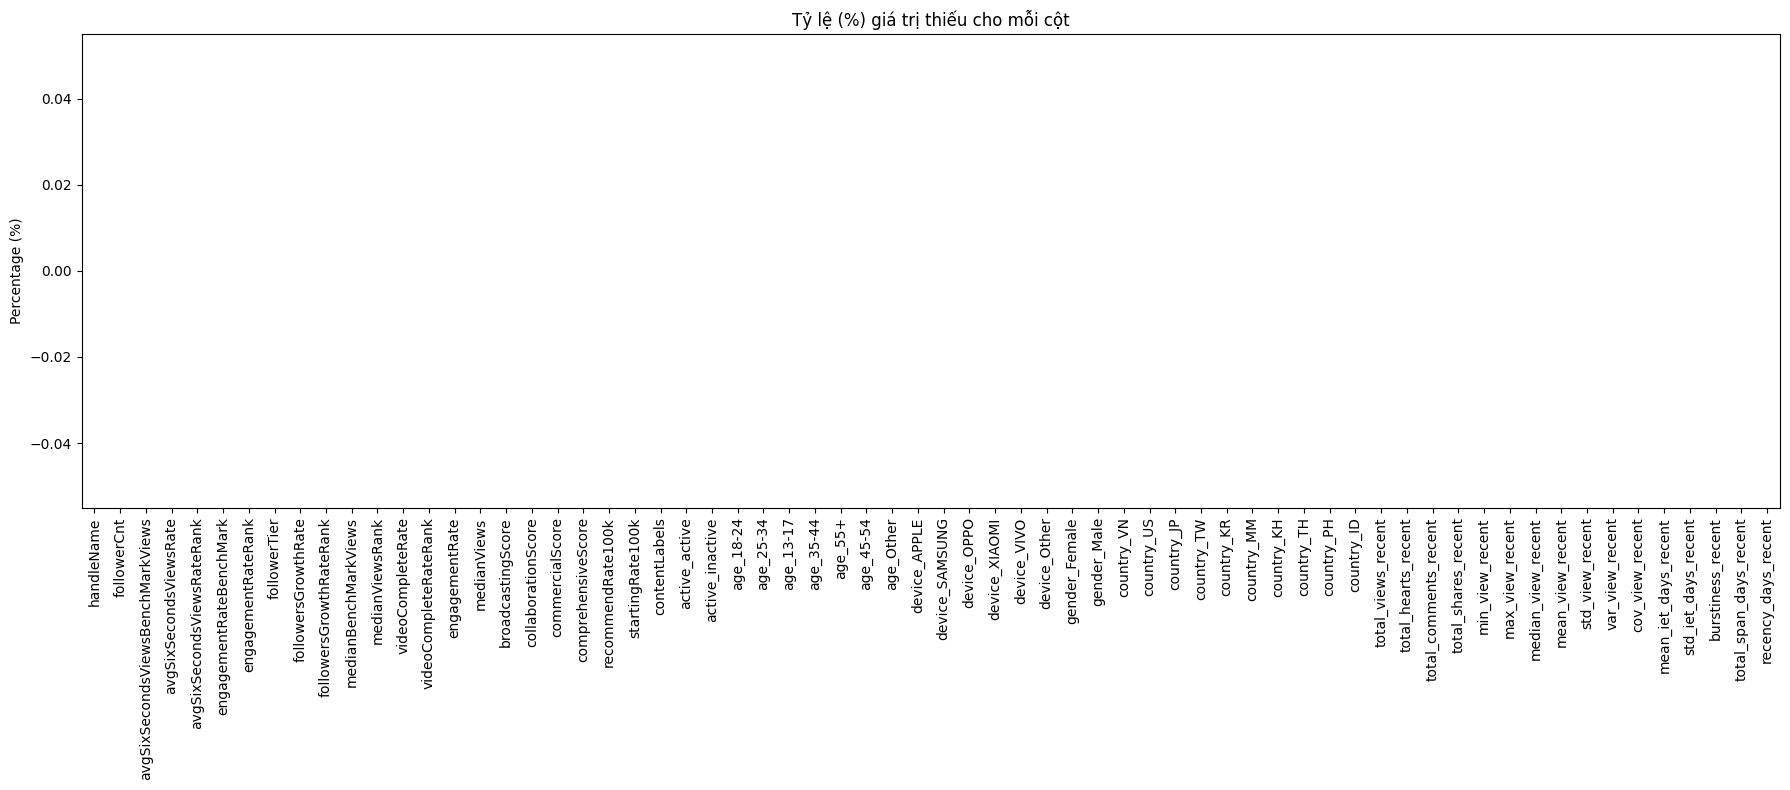

In [ ]:
a = df.isna().mean() * 100  

plt.figure(figsize=(18, 8))
a.plot(kind='bar')

plt.title('Tỷ lệ (%) giá trị thiếu cho mỗi cột')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

Shape trước: (5092, 66)
Shape sau: (5089, 66)


In [19]:
creator_df.describe()

,total_views_recent,total_hearts_recent,total_comments_recent,total_shares_recent,min_view_recent,max_view_recent,median_view_recent,mean_view_recent,std_view_recent,var_view_recent,cov_view_recent,mean_iet_days_recent,std_iet_days_recent,burstiness_recent,total_span_days_recent,recency_days_recent
count,5.092000e+03,5.092000e+03,5092.000000,5.092000e+03,5.092000e+03,5.092000e+03,5.092000e+03,5.092000e+03,5.091000e+03,5.091000e+03,5089.000000,5091.000000,5091.000000,5091.000000,5092.000000,5092.000000
mean,3.151484e+06,3.065637e+04,1109.331304,3.065637e+04,2.147777e+04,1.104417e+06,1.037799e+05,2.165871e+05,3.072373e+05,2.160478e+12,1.333929,4.526985,5.308069,-0.047571,59.785427,6.286705
std,1.476751e+07,4.176533e+05,2932.223207,4.176533e+05,5.537019e+04,4.177108e+06,3.024877e+05,9.915261e+05,1.437529e+06,1.207224e+14,0.640688,9.396218,13.673007,0.212067,100.533589,12.251848
min,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.116793,0.000300,0.000000,-1.000000,0.000000,0.002512
25%,5.053735e+05,6.747500e+02,210.750000,6.747500e+02,2.356500e+03,1.342935e+05,1.407075e+04,3.482570e+04,3.564731e+04,1.270731e+09,0.869974,1.054627,0.738163,-0.174712,14.115240,1.510333
50%,1.194320e+06,3.039000e+03,458.000000,3.039000e+03,6.863500e+03,3.658810e+05,3.587375e+04,8.176510e+04,9.981830e+04,9.963693e+09,1.232145,2.213924,1.863015,-0.043830,30.005145,2.493084
75%,2.825418e+06,1.192425e+04,975.500000,1.192425e+04,1.955025e+04,1.001185e+06,9.006000e+04,1.952875e+05,2.765434e+05,7.647623e+10,1.674548,4.916208,5.144432,0.085315,67.504687,5.341620
max,9.634141e+08,2.584405e+07,83835.000000,2.584405e+07,1.078210e+06,2.509662e+08,1.054987e+07,6.422761e+07,9.279589e+07,8.611078e+15,3.799741,288.538368,278.658670,0.578189,2226.357731,295.462616


In [20]:
df.describe()

,followerCnt,avgSixSecondsViewsBenchMarkViews,avgSixSecondsViewsRate,avgSixSecondsViewsRateRank,engagementRateBenchMark,engagementRateRank,followerTier,followersGrowthRate,followersGrowthRateRank,medianBenchMarkViews,...,median_view_recent,mean_view_recent,std_view_recent,var_view_recent,cov_view_recent,mean_iet_days_recent,std_iet_days_recent,burstiness_recent,total_span_days_recent,recency_days_recent
count,5.092000e+03,5092.000000,5092.000000,5092.000000,5092.000000,5092.000000,5092.000000,5092.000000,5092.000000,5092.000000,...,5.092000e+03,5.092000e+03,5.091000e+03,5.091000e+03,5089.000000,5091.000000,5091.000000,5091.000000,5092.000000,5092.000000
mean,4.079342e+05,0.427831,0.370985,0.436701,0.042889,0.450905,3.965240,17.367203,0.591998,19979.225648,...,1.037799e+05,2.165871e+05,3.072373e+05,2.160478e+12,1.333929,4.526985,5.308069,-0.047571,59.785427,6.286705
std,9.477505e+05,0.028767,0.177580,0.309614,0.004371,0.262235,0.903609,813.057179,0.350329,50786.458160,...,3.024877e+05,9.915261e+05,1.437529e+06,1.207224e+14,0.640688,9.396218,13.673007,0.212067,100.533589,12.251848
min,6.594000e+03,0.000000,0.000000,0.010000,0.000000,0.010000,2.000000,-0.154088,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.116793,0.000300,0.000000,-1.000000,0.000000,0.002512
25%,7.959650e+04,0.405700,0.262850,0.170975,0.040000,0.225000,3.000000,-0.001874,0.235457,1202.000000,...,1.407075e+04,3.482570e+04,3.564731e+04,1.270731e+09,0.869974,1.054627,0.738163,-0.174712,14.115240,1.510333
50%,1.683025e+05,0.442800,0.396500,0.366050,0.040000,0.433700,4.000000,0.003730,0.729495,8746.000000,...,3.587375e+04,8.176510e+04,9.981830e+04,9.963693e+09,1.232145,2.213924,1.863015,-0.043830,30.005145,2.493084
75%,3.668412e+05,0.443100,0.506725,0.683625,0.048800,0.656925,4.000000,0.031116,0.901045,8764.000000,...,9.006000e+04,1.952875e+05,2.765434e+05,7.647623e+10,1.674548,4.916208,5.144432,0.085315,67.504687,5.341620
max,2.114156e+07,0.521000,0.817800,1.000000,0.048800,1.000000,8.000000,42037.000000,0.999992,735130.000000,...,1.054987e+07,6.422761e+07,9.279589e+07,8.611078e+15,3.799741,288.538368,278.658670,0.578189,2226.357731,295.462616


In [ ]:
# df_clean.to_csv('creator_processed_3.csv', index=False)